# 1 step cat

In [ ]:
# Define the optimal parameters for the two input states (from the paper)
r1 = 0.73        # Squeezing for state from n=1 outcome
alpha1 = 0.10    # Displacement amplitude for state from n=1 outcome

r2 = 1.31        # Squeezing for state from n=2 outcome
alpha2 = 2.12    # Displacement amplitude for state from n=2 outcome


In [ ]:
import strawberryfields as sf
from strawberryfields import ops
from strawberryfields.ops import Sgate, BSgate, MeasureFock
from strawberryfields.tdm import shift_by
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

# simple

In [ ]:
tau =  0.367
theta_bs = np.arccos(tau)

# Squeezing parameter
r = 1.38  # Adjust as needed

# Rotation angle
phi = np.pi/2  # Adjust as needed

# Create a 4-mode quantum program
prog = sf.Program(4)

with prog.context as q:
    # Apply squeezing gates to initialize the states
    ops.Sgate(r) | q[0]
    ops.Sgate(-r) | q[1]
    ops.Sgate(r) | q[2]
    ops.Sgate(-r) | q[3]

    # Apply beam splitter gates
    ops.BSgate(theta_bs) | (q[0], q[1])
    ops.BSgate(theta_bs) | (q[2], q[3])

    # Perform photon number resolving measurements on modes 0 and 2
    # Using select parameter for post-selection on n1=1 and n2=2 outcomes
    ops.MeasureFock(select=1) | q[0]
    ops.MeasureFock(select=2) | q[2]

    # Since we're post-selecting, we can apply the conditional operations directly
    ops.Rgate(phi) | q[3]
    ops.CZgate() | (q[1], q[3])
    ops.MeasureHomodyne(phi=np.pi / 2) | q[3]
    # ops.MeasureHomodyne(phi=0) | q[3]

    # ops.MeasureFock(select=0) | q[3]

# Use the Fock backend (adjust cutoff_dim as needed for convergence)
# eng = sf.Engine("fock", backend_options={"cutoff_dim": 10})
eng = sf.Engine("gaussian")

result = eng.run(prog)

# Output the final state or relevant results
print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()                                              # Display the plot


# more optimized

In [ ]:
tau =  0.367
theta_bs = np.arccos(tau)
# theta_bs = 1.8
# Squeezing parameter
r = 1.38  # Adjust as needed

# Rotation angle
phi = np.pi/2  # Adjust as needed

# Create a 4-mode quantum program
prog = sf.Program(3)

with prog.context as q:
    # Apply squeezing gates to initialize the states
    ops.Sgate(r) | q[0]
    ops.Sgate(-r) | q[1]
    ops.BSgate(theta_bs) | (q[0], q[1])
    ops.MeasureFock(select=1) | q[0]

    ops.Sgate(r) | q[0]
    ops.Sgate(-r) | q[2]
    ops.BSgate(theta_bs) | (q[0], q[2])
    ops.MeasureFock(select=2) | q[0]


    ops.Rgate(phi) | q[2]
    ops.CZgate() | (q[2], q[1])
    ops.MeasureHomodyne(phi=np.pi / 2, select=0) | q[2]


# Use the Fock backend (adjust cutoff_dim as needed for convergence)
eng = sf.Engine("fock", backend_options={"cutoff_dim": 30})
# eng = sf.Engine("gaussian")

result = eng.run(prog)

# Output the final state or relevant results
print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()                                              # Display the plot


# no post-select

In [ ]:
tau =  0.367
theta_bs = np.arccos(tau)

# Squeezing parameter
r = 1.38  # Adjust as needed

# Rotation angle
phi = np.pi/2  # Adjust as needed

# Create a 4-mode quantum program
prog = sf.Program(4)

with prog.context as q:
    # Apply squeezing gates to initialize the states
    ops.Sgate(r) | q[0]
    ops.Sgate(-r) | q[1]
    ops.Sgate(r) | q[2]
    ops.Sgate(-r) | q[3]

    # Apply beam splitter gates
    ops.BSgate(theta_bs) | (q[0], q[1])
    ops.BSgate(theta_bs) | (q[2], q[3])

    # Perform photon number resolving measurements on modes 0 and 2
    ops.MeasureFock() | q[0]
    ops.MeasureFock() | q[2]

    # Conditional operations based on measurement outcomes
    # Assuming outcomes n1=1 and n2=2 for simplicity

    # n1, n2 = q[0].par, q[2].par
    # if n1 == 1 and n2 == 2:
    
    # Apply rotation gate to mode 3
    ops.Rgate(phi) | q[3]

    # Apply CZ gate between modes 1 and 3
    ops.CZgate() | (q[1], q[3])

    # Perform homodyne measurement in momentum quadrature (P = 0)
    ops.MeasureHomodyne(phi=np.pi / 2) | q[3]

    # ops.MeasureFock() | q[3]

# Use the Fock backend (adjust cutoff_dim as needed for convergence)
eng = sf.Engine("fock", backend_options={"cutoff_dim": 10})
# eng = sf.Engine("gaussian")
result = eng.run(prog)

# Output the final state or relevant results
print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()                                              # Display the plot


# gkp from cat (Anteneh 2024)

In [ ]:

# Simulation and cat state parameters
nmodes = 2
cutoff = 30
q = 4.0
p = 0.0
hbar = 2
# alpha = (q + 1j * p) / np.sqrt(2 * hbar)
alpha = 3 
k = 1

# Squeezing parameter
r = 1.38  # Adjust as needed

prog_cat_bosonic = sf.Program(nmodes)

with prog_cat_bosonic.context as q:
    ops.Catstate(a=np.absolute(alpha), phi=np.angle(alpha), p=k) | q[0]
    ops.Rgate(np.pi/2) | q[0]
    ops.Sgate(-r) | q[0]

    ops.Catstate(a=np.absolute(alpha), phi=np.angle(alpha), p=k) | q[1]
    ops.Sgate(r) | q[1]

    ops.CZgate() | (q[0], q[1])

    ops.MeasureHomodyne(phi=np.pi / 2) | q[1]


eng = sf.Engine("bosonic", backend_options={"hbar": hbar})
result = eng.run(prog_cat_bosonic)

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=0, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()  

# main circuit Anteneh

In [ ]:
# Parameters
m = 4  # Number of steps in the loop
r0 = 1.38  # Squeezing parameter
tau_1 = tau =  0.367
tau_2 = [0] * (m - 1) + [1]  # Switchable mirror for VBS2
r = [r0, -r0] * int(m/2)
# Convert transmission coefficient to beam splitter angle
theta_1 = np.arccos(tau_1)
theta_2 = np.arccos(tau_2)
# Create a Strawberry Fields program
prog = sf.Program(2)  # Two modes: one for the loop and one for output

with prog.context as q:
    for j in range(m):
        # Initialize mode 0 with a squeezed vacuum state
        Sgate(r[j]) | q[1]

        # Apply variable beam splitter (VBS1)
        BSgate(theta_1, 0) | (q[0], q[1])

        # Photon-number-resolving measurement (PNR)
        MeasureFock() | q[0]

        # # Apply phase-stable loop and VBS2
        # BSgate(theta_2[j], 0) | (q[0], q[1])  # Fully reflective mirror

        if tau_2[j] == 0:
            q = shift_by(q, 1)


# Run the simulation using the Fock backend
eng = sf.Engine("fock", backend_options={"cutoff_dim": 50})
result = eng.run(prog)

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()


## TDM

In [ ]:
# Parameters
m = 4  # Number of steps in the loop
r0 = 1.38  # Squeezing parameter
tau_1 = [0.367] * m
tau_2 = [0] * (m - 1) + [1]  # Switchable mirror for VBS2
r = [r0, -r0] * int(m/2)
# Convert transmission coefficient to beam splitter angle
theta_1 = np.arccos(tau_1)
theta_2 = np.arccos(tau_2)
# Create a Strawberry Fields program
prog = sf.TDMProgram(2)  # Two modes: one for the loop and one for output

with prog.context(r, theta_1, theta_2) as (p, q):
    for j in range(m):
        # Initialize mode 0 with a squeezed vacuum state
        Sgate(p[0]) | q[1]

        # Apply variable beam splitter (VBS1)
        BSgate(p[1], 0) | (q[0], q[1])

        # Photon-number-resolving measurement (PNR)
        MeasureFock() | q[0]


# Run the simulation using the Fock backend
eng = sf.Engine("fock", backend_options={"cutoff_dim": 50})
result = eng.run(prog)

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=0, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()


## for loop

### one iteration

Final state: <FockState: num_modes=2, cutoff=20, pure=True, hbar=2>
[[3]]


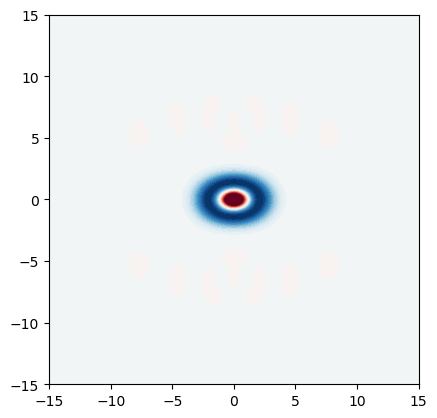

In [43]:
np.random.seed = 42

# Parameters
m = 4  # Number of steps in the loop
r0 = 1.38  # Squeezing parameter
tau_1 =  0.367
tau_2 = [0] * (m - 1) + [1]  # Switchable mirror for VBS2
r = [r0, -r0] * int(m/2)

# # Convert transmission coefficient to beam splitter angle
# theta_1 = np.arccos(tau_1)
# theta_2 = np.arccos(tau_2)

# Create a Strawberry Fields program
prog = sf.Program(2)  # Two modes: one for the loop and one for output
eng = sf.Engine("fock", backend_options={"cutoff_dim": 20})
results = []

theta_1 = np.arccos(tau_1)
r = r0 * (-1) ** 11 # This will alternate between r0 and -r0 for each iteration

# Create a new program for each iteration
prog = sf.Program(2)

with prog.context as q:
    # Initialize mode 0 with a squeezed vacuum state
    Sgate(r) | q[1]

    # Apply variable beam splitter (VBS1)
    BSgate(theta_1, 0) | (q[0], q[1])

    # Photon-number-resolving measurement (PNR)
    MeasureFock(select = 3) | q[0]

    if tau_2[j] == 0:
        q = shift_by(q, 1)

# Run the simulation and store result
result = eng.run(prog)

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()



### for loop outside

Final state: <FockState: num_modes=2, cutoff=20, pure=True, hbar=2>
[[4]]


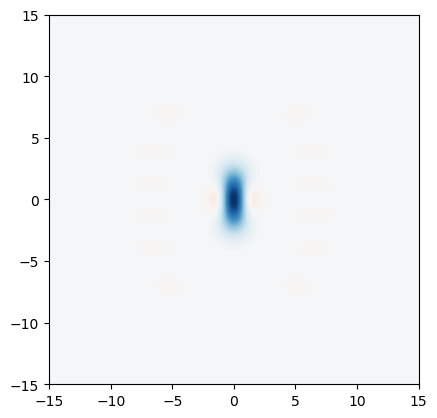

In [ ]:
np.random.seed = 42

# Parameters
m = 5  # Number of steps in the loop
r0 = 1.38  # Squeezing parameter
tau_1 = 0.367
tau_2 = [0] * (m - 1) + [1]  # Switchable mirror for VBS2
r = [r0, -r0] * int(m / 2)

# # Convert transmission coefficient to beam splitter angle
# theta_1 = np.arccos(tau_1)
# theta_2 = np.arccos(tau_2)

# Create a Strawberry Fields program
prog = sf.Program(2)  # Two modes: one for the loop and one for output
eng = sf.Engine("fock", backend_options={"cutoff_dim": 20})
results = []
for j in range(m):
    theta_1 = np.arccos(tau_1)
    r = r0 * (-1) ** j # This will alternate between r0 and -r0 for each iteration

    # Create a new program for each iteration
    prog = sf.Program(2)

    with prog.context as q:
        # Initialize mode 0 with a squeezed vacuum state
        Sgate(r) | q[1]

        # Apply variable beam splitter (VBS1)
        BSgate(theta_1, 0) | (q[0], q[1])

        # Photon-number-resolving measurement (PNR)
        MeasureFock(select=j) | q[0]

        if tau_2[j] == 0:
            q = shift_by(q, 1)


# Run the simulation and store result
result = eng.run(prog)
results.append(result)

# Use the last result for plotting
result = results[-1]

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()



### for loop inside

In [ ]:
np.random.seed = 42

# Parameters
m = 4  # Number of steps in the loop
r0 = 1.38  # Squeezing parameter
tau_1 =  0.367
tau_2 = [0] * (m - 1) + [1]  # Switchable mirror for VBS2
r = [r0, -r0] * int(m/2)

# # Convert transmission coefficient to beam splitter angle
# theta_1 = np.arccos(tau_1)
# theta_2 = np.arccos(tau_2)

# Create a Strawberry Fields program
prog = sf.Program(2)  # Two modes: one for the loop and one for output
eng = sf.Engine("fock", backend_options={"cutoff_dim": 20})
results = []
with prog.context as q:
    for j in range(m):
        theta_1 = np.arccos(tau_1)
        r = r0 * (-1) ** j # This will alternate between r0 and -r0 for each iteration
        
    # Initialize mode 0 with a squeezed vacuum state
    Sgate(r) | q[1]

    # Apply variable beam splitter (VBS1)
    BSgate(theta_1, 0) | (q[0], q[1])

    # Photon-number-resolving measurement (PNR)
    MeasureFock(select = 4) | q[0]

    if tau_2[j] == 0:
        q = shift_by(q, 1)
    
result = eng.run(prog)

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()



## reflective mirror

In [ ]:
# Parameters
m = 4  # Number of steps in the loop
r0 = 1.38  # Squeezing parameter
tau_1 = tau =  0.367
tau_2 = [0] * (m - 1) + [1]  # Switchable mirror for VBS2
r = [r0, -r0] * int(m/2)
# Convert transmission coefficient to beam splitter angle
theta_1 = np.arccos(tau_1)
theta_2 = np.arccos(tau_2)
# Create a Strawberry Fields program
prog = sf.Program(2)  # Two modes: one for the loop and one for output

with prog.context as q:
        # Initialize mode
        ops.Fock(40) | q[1]
        # Sgate(r0) | q[1]

        # BSgate(np.pi/2, 0) | (q[0], q[1]) # Fully reflective mirror
        BSgate(0, 0) | (q[0], q[1])  # Fully transsmissive mirror


# Run the simulation using the Fock backend
eng = sf.Engine("fock", backend_options={"cutoff_dim": 50})
result = eng.run(prog)

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()
